In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib

In [7]:
diabetes=load_diabetes()
X=diabetes.data
df = pd.DataFrame(X, columns=diabetes.feature_names)
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
inertia=[]
for k in range(1,11):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(X_scaled)
        inertia.append(kmeans.inertia_)

In [10]:
for i, val in enumerate(inertia, start=1):
    print(f"Number of clusters = {i}, Inertia = {val:.2f}")

Number of clusters = 1, Inertia = 4420.00
Number of clusters = 2, Inertia = 3176.67
Number of clusters = 3, Inertia = 2879.50
Number of clusters = 4, Inertia = 2659.23
Number of clusters = 5, Inertia = 2453.24
Number of clusters = 6, Inertia = 2340.56
Number of clusters = 7, Inertia = 2210.96
Number of clusters = 8, Inertia = 2112.02
Number of clusters = 9, Inertia = 2057.68
Number of clusters = 10, Inertia = 2015.60


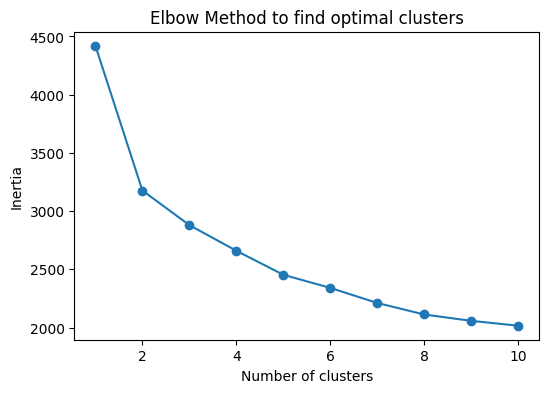

In [11]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method to find optimal clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [12]:
kmeans=KMeans(n_clusters=3,random_state=42)
clusters=kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  Cluster  
0 -0.002592  0.019907 -0.017646        2  
1 -0.039493 -0.068332 -0.092204        0  
2 -0.002592  0.002861 -0.025930        2  
3  0.034309  0.022688 -0.009362        2  
4 -0.002592 -0.031988 -0.046641        0  


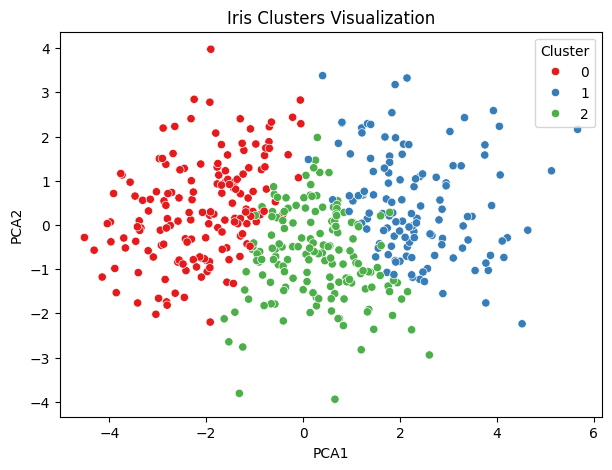

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['PCA1'] = X_pca[:,0]
df['PCA2'] = X_pca[:,1]

# Plot clusters
plt.figure(figsize=(7,5))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster', data=df, palette='Set1')
plt.title("Iris Clusters Visualization")
plt.show()

In [14]:
joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']